<a href="https://colab.research.google.com/github/fahadabdullah-lab/smap-dispatch-gee-south-texas/blob/main/notebooks/03_dispatch_physics_daily.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **03_dispatch_physics_daily.ipynb**

### **Cell 1 — Install + imports**

In [ ]:
!pip -q install earthengine-api geemap

import ee
import geemap

### **Cell 2 — Authenticate + initialize**

In [ ]:
ee.Authenticate()
ee.Initialize(project='ee-fafahadabdullah')
print("✅ Earth Engine initialized.")

### **Cell 3 — Parameters**

In [ ]:
TEST_DATE = "2021-08-15"
start = ee.Date(TEST_DATE)
end   = start.advance(1, "day")

# Local triangle settings
NDVI_S = 0.15
NDVI_V = 0.90

# For a local triangle, it’s often better to use a moderate window.
# We'll compute triangle stats inside AOI; later we can also add a buffered AOI.
USE_BUFFERED_AOI_FOR_TRIANGLE = True
TRIANGLE_BUFFER_M = 50000  # 50 km buffer around AOI

# AOI (same as earlier)
def get_south_texas_aoi():
    bounds = [-97.6, 25.8, -97.0, 26.4]
    return ee.Geometry.Rectangle(bounds)

aoi = get_south_texas_aoi()
tri_aoi = aoi.buffer(TRIANGLE_BUFFER_M) if USE_BUFFERED_AOI_FOR_TRIANGLE else aoi

print("📅 Date:", TEST_DATE)
print("🧭 AOI ready. Buffered for triangle:", USE_BUFFERED_AOI_FOR_TRIANGLE)

## **Cell 4 — Pull datasets (same as Notebook 02)**

In [ ]:
# ---------------- SMAP L3 (36 km) ----------------
smap_ic = (ee.ImageCollection("NASA/SMAP/SPL3SMP_E/005")
           .filterDate(start, end)
           .filterBounds(aoi))
smap_img = ee.Image(smap_ic.first())
smap_sm  = smap_img.select("soil_moisture_am").clip(aoi)

print("SMAP images:", smap_ic.size().getInfo())

# ---------------- MODIS Terra Reflectance (daily) ----------------
mod09_ic = (ee.ImageCollection("MODIS/061/MOD09GA")
            .filterDate(start, end)
            .filterBounds(aoi))
mod09 = ee.Image(mod09_ic.first())
print("MOD09GA images:", mod09_ic.size().getInfo())

state = mod09.select("state_1km")
cloud_state = state.bitwiseAnd(3)  # bits 0-1
clear_mask = cloud_state.eq(0)

red = mod09.select("sur_refl_b01").updateMask(clear_mask).multiply(0.0001)
nir = mod09.select("sur_refl_b02").updateMask(clear_mask).multiply(0.0001)

# ---------------- MODIS Terra LST (daily, 1 km) ----------------
lst_ic = (ee.ImageCollection("MODIS/061/MOD11A1")
          .filterDate(start, end)
          .filterBounds(aoi))
lst_img = ee.Image(lst_ic.first())
print("MOD11A1 images:", lst_ic.size().getInfo())

lst = lst_img.select("LST_Day_1km").multiply(0.02)  # Kelvin
qc  = lst_img.select("QC_Day")
lst_good = qc.bitwiseAnd(3).eq(0)
lst = lst.updateMask(lst_good)

# clip to AOI for outputs
red = red.clip(aoi)
nir = nir.clip(aoi)
lst = lst.clip(aoi)

### **Cell 5 — Compute NDVI + FVC**

In [ ]:
ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")

# FVC formula (same spirit as SHMS_py)
fvc = ndvi.subtract(NDVI_S).divide(NDVI_V - NDVI_S).rename("FVC")

# Clamp to [0,1] physically
fvc = fvc.clamp(0, 1)

### **Cell 6 — Local Triangle: estimate Ts_min and Ts_max**

We will derive soil endmembers from the dry edge and wet edge using NDVI and LST distribution.

A clean, robust approximation for local triangle in GEE:

Define “bare” pixels: low NDVI range (e.g., NDVI < 0.2)

Define “veg” pixels: high NDVI (e.g., NDVI > 0.7)

Within bare pixels:

Ts_max ≈ high percentile of LST (dry edge)

Ts_min ≈ low percentile of LST (wet edge)

This is simpler than SHMS_py’s triangle intersection math but is standard and stable in practice.

In [ ]:
# Work on triangle AOI (buffered if enabled)
ndvi_tri = ndvi.clip(tri_aoi)
lst_tri  = lst.clip(tri_aoi)

bare = ndvi_tri.lt(0.2)
veg  = ndvi_tri.gt(0.7)

# Percentiles for robust endmembers
# Tsmax: 95th percentile of bare-soil LST
# Tsmin: 5th percentile of bare-soil LST
scale_lst = 1000

ts_stats = lst_tri.updateMask(bare).reduceRegion(
    reducer=ee.Reducer.percentile([5, 95]),
    geometry=tri_aoi,
    scale=scale_lst,
    bestEffort=True,
    maxPixels=1e13
)

Tsmin = ee.Number(ts_stats.get("LST_Day_1km_p5"))
Tsmax = ee.Number(ts_stats.get("LST_Day_1km_p95"))

print("✅ Tsmin (K):", Tsmin.getInfo())
print("✅ Tsmax (K):", Tsmax.getInfo())

### **Cell 7 — Compute Soil Temperature Ts (from SHMS structure)**

In SHMS_py they compute Tv first.
Here’s a stable local approach:

Estimate Tv as median LST over dense vegetation pixels (NDVI > 0.7)
(This approximates canopy temperature)

In [ ]:
tv_stats = lst_tri.updateMask(veg).reduceRegion(
    reducer=ee.Reducer.median(),
    geometry=tri_aoi,
    scale=scale_lst,
    bestEffort=True,
    maxPixels=1e13
)

Tv = ee.Number(tv_stats.get("LST_Day_1km"))
print("✅ Tv (K):", Tv.getInfo())

# Create constant images for Tsmin/Tsmax/Tv
Tv_img    = ee.Image.constant(Tv).rename("Tv")
Tsmin_img = ee.Image.constant(Tsmin).rename("Tsmin")
Tsmax_img = ee.Image.constant(Tsmax).rename("Tsmax")

# Ts = (Tmodis - FVC*Tv)/(1-FVC)
Ts = lst.subtract(fvc.multiply(Tv_img)).divide(ee.Image.constant(1).subtract(fvc)).rename("Ts")

### **Cell 8 — SEE at 1 km**

In [ ]:
SEE = Tsmax_img.subtract(Ts).divide(Tsmax_img.subtract(Tsmin_img)).rename("SEE")

# Clamp to [0,1]
SEE = SEE.clamp(0, 1)

### **Cell 9 — Aggregate SEE to SMAP scale + compute SMp**

We need:

SEE_mean at SMAP scale

SMp using SHMS equation

We do this robustly by:

Resample SEE to SMAP resolution using mean

Compute SMp = πSM / arccos(1-2SEE_mean)

In [ ]:
# Create an image with SMAP projection to force aggregation on SMAP grid
smap_proj = smap_sm.projection()

# Aggregate SEE to SMAP scale
SEE_mean = SEE.reduceResolution(
    reducer=ee.Reducer.mean(),
    maxPixels=1024
).reproject(smap_proj).rename("SEE_mean")

# Avoid invalid arccos arguments
SEE_mean = SEE_mean.clamp(1e-6, 1 - 1e-6)

pi = ee.Image.constant(3.141592653589793)

SMp = (pi.multiply(smap_sm)
       .divide( (ee.Image.constant(1).subtract(SEE_mean.multiply(2))).acos() )
       ).rename("SMp")

### **Cell 10 — DISPATCH disaggregation to 1 km**

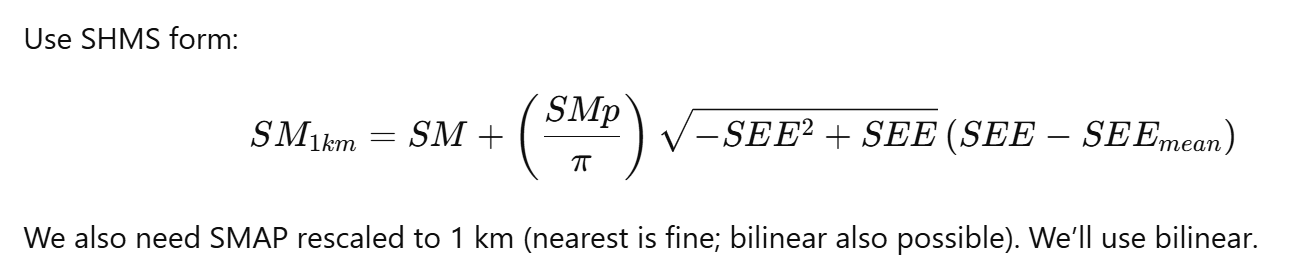

In [ ]:
# Rescale SMAP soil moisture to 1 km grid
SM_rescaled = smap_sm.resample("bilinear").reproject(lst.projection()).rename("SM_rescaled")

# Rescale SEE_mean to 1 km as well
SEE_mean_1km = SEE_mean.resample("bilinear").reproject(lst.projection()).rename("SEE_mean_1km")

# D term
D = (SMp.resample("bilinear").reproject(lst.projection())
     .divide(pi)
     .multiply( (SEE.multiply(-1).pow(2).add(SEE)).sqrt() )
     ).rename("D")

SM_1km = (SM_rescaled
          .add(D.multiply(SEE.subtract(SEE_mean_1km)))
          ).rename("SM_1km")

Clamping to plausible soil moisture range:

In [ ]:
SM_1km = SM_1km.clamp(0, 0.6)

### **Cell 11 — Visualize outputs**

In [ ]:
Map = geemap.Map(center=[26.1, -97.3], zoom=9)

vis_smap = {"min": 0.0, "max": 0.5}
vis_lst  = {"min": 290, "max": 330}
vis_see  = {"min": 0.0, "max": 1.0}
vis_sm1  = {"min": 0.0, "max": 0.5}

Map.addLayer(aoi, {"color":"yellow"}, "AOI")
Map.addLayer(smap_sm, vis_smap, "SMAP SM (36 km)")
Map.addLayer(lst, vis_lst, "MODIS LST (K)")
Map.addLayer(SEE, vis_see, "SEE (1 km)")
Map.addLayer(SM_1km, vis_sm1, "DISPATCH SM (1 km)")
Map

### **Cell 12 — Export to Google Drive**

In [ ]:
task = ee.batch.Export.image.toDrive(
    image=SM_1km,
    description=f"DISPATCH_SM_1km_{TEST_DATE}",
    folder="GEE_DISPATCH_SM",
    fileNamePrefix=f"DISPATCH_SM_1km_{TEST_DATE}",
    region=aoi,
    scale=1000,
    crs="EPSG:4326",
    maxPixels=1e13
)
task.start()
print("🚀 Export started. Check Earth Engine Tasks tab in Colab or EE Code Editor.")